In [116]:
# Import block
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os


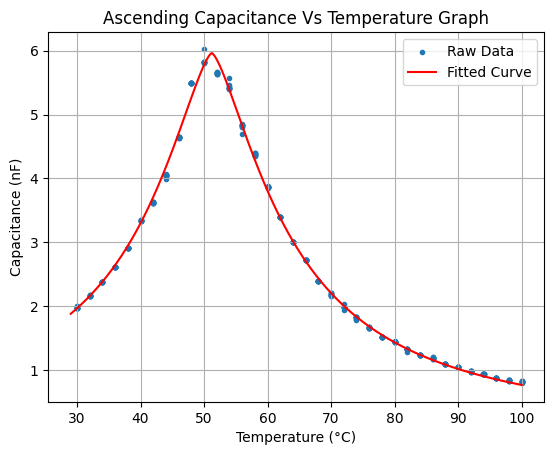

The Parameters for the Ascending Curve are: Max Capacitance 5.962841820135798, K 0.02439672945999764, gamma 1.4480439711325717, Tc 51.21255702689708


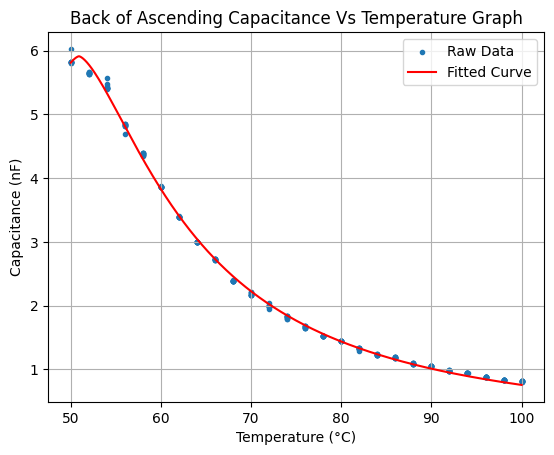

The Parameters for the Backslice Ascending Curve are: Max Capacitance 5.913177507680638, K 0.0198799330704437, gamma 1.5002485163637351, Tc 50.91344316267508
The Parameters for the Descending Curve are: Max Capacitance 6.299487477668374, K 0.021528743103739693, gamma 1.4922700845217354, Tc 50.751389092274636


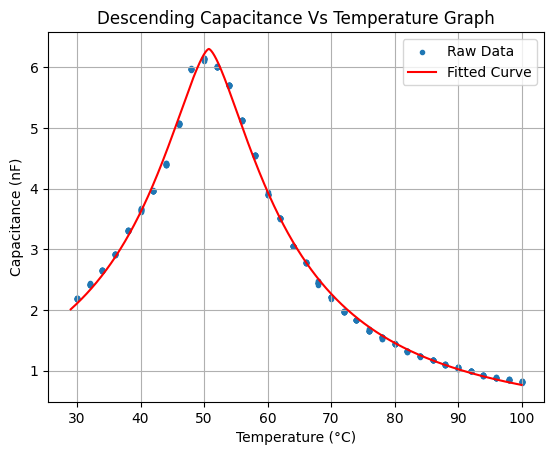

The Parameters for the Backslice Descending Curve are: Max Capacitance 6.269563742281741, K 0.021781716615680083, gamma 1.495088101035926, Tc 50.96067273141793


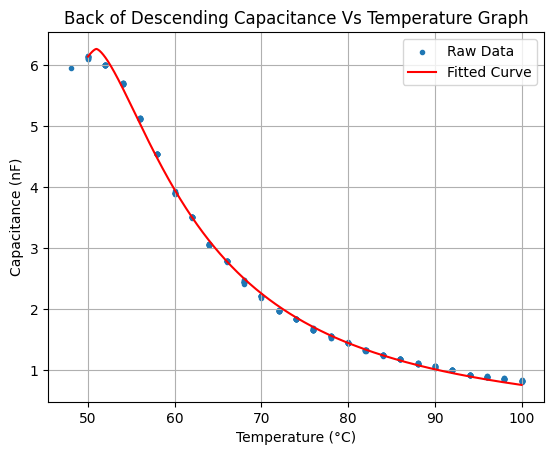

In [117]:
timeA, tempA, capA = np.genfromtxt("30to100(dT = 2).lvm", delimiter = "\t", skip_header=0).T
timeD, tempD, capD = np.genfromtxt("100to30(dT = -2).lvm", delimiter = "\t").T


# curvefitting


def Capacitance(Temp, Cmax, K, Gamma, Tc):

    # had to add base as floating point errors gave negative values, which become imaginary / undefined behaviour.
    base = np.abs(Temp - Tc)
    return Cmax / (1.0 + K * base**Gamma + 1e-12)

# Setting values according to Q1

guessesA = [np.max(capA), 0.01, 1.8, tempA[np.argmin(np.abs(capA - np.max(capA)/2))]]
pOpt, pCov = curve_fit(Capacitance, tempA, capA)

fitTempA = np.linspace(29, 100, 10000)
fitCapA = Capacitance(fitTempA, *pOpt)

## plot stuff

plt.scatter(tempA, capA, marker = ".", label = "Raw Data")
plt.plot(fitTempA, fitCapA, color = 'red', label = "Fitted Curve")
plt.xlabel("Temperature (°C)")
plt.ylabel("Capacitance (nF)")
plt.title("Ascending Capacitance Vs Temperature Graph")
plt.grid(True)
plt.legend()
plt.savefig("Graphs/Ascending Capacitance Vs Temperature Graph.pdf")
plt.show()

print(f"The Parameters for the Ascending Curve are: Max Capacitance {pOpt[0]}, K {pOpt[1]}, gamma {pOpt[2]}, Tc {pOpt[3]}")

backSlice = 100

pOpt, pCov = curve_fit(Capacitance, tempA[backSlice:], capA[backSlice:])

fitTempA = np.linspace(50, 100, 10000)
fitCapA = Capacitance(fitTempA, *pOpt)


plt.scatter(tempA[backSlice:], capA[backSlice:], marker = ".", label = "Raw Data")
plt.plot(fitTempA, fitCapA, color = 'red', label = "Fitted Curve")
plt.xlabel("Temperature (°C)")
plt.ylabel("Capacitance (nF)")
plt.title("Back of Ascending Capacitance Vs Temperature Graph")
plt.grid(True)
plt.legend()
plt.savefig("Graphs/Backslice Ascending Capacitance Vs Temperature Graph.pdf")
plt.show()


# print(pOpt)

print(f"The Parameters for the Backslice Ascending Curve are: Max Capacitance {pOpt[0]}, K {pOpt[1]}, gamma {pOpt[2]}, Tc {pOpt[3]}")

guessesD = [np.max(capD), 0.01, 1.8, tempD[np.argmin(np.abs(capD - np.max(capD)/2))]]
pOpt, pCov = curve_fit(Capacitance, tempD, capD)

fitTempD = np.linspace(29, 100, 10000)
fitCapD = Capacitance(fitTempD, *pOpt)


print(f"The Parameters for the Descending Curve are: Max Capacitance {pOpt[0]}, K {pOpt[1]}, gamma {pOpt[2]}, Tc {pOpt[3]}")


plt.scatter(tempD, capD, marker = ".", label = "Raw Data")
plt.plot(fitTempD, fitCapD, color = 'red', label = "Fitted Curve")
plt.xlabel("Temperature (°C)")
plt.ylabel("Capacitance (nF)")
plt.title("Descending Capacitance Vs Temperature Graph")
plt.grid(True)
plt.legend()
plt.savefig("Graphs/Descending Capacitance Vs Temperature Graph.pdf")
plt.show()


backSlice = 361 - 100

pOpt, pCov = curve_fit(Capacitance, tempD[:backSlice], capD[:backSlice])

fitTempD = np.linspace(50, 100, 10000)
fitCapD = Capacitance(fitTempD, *pOpt)

print(f"The Parameters for the Backslice Descending Curve are: Max Capacitance {pOpt[0]}, K {pOpt[1]}, gamma {pOpt[2]}, Tc {pOpt[3]}")


plt.scatter(tempD[:backSlice], capD[:backSlice], marker = ".", label = "Raw Data")
plt.plot(fitTempD, fitCapD, color = 'red', label = "Fitted Curve")
plt.xlabel("Temperature (°C)")
plt.ylabel("Capacitance (nF)")
plt.title("Back of Descending Capacitance Vs Temperature Graph")
plt.grid(True)
plt.legend()
plt.savefig("Graphs/Backslice Descending Capacitance Vs Temperature Graph.pdf")
plt.show()






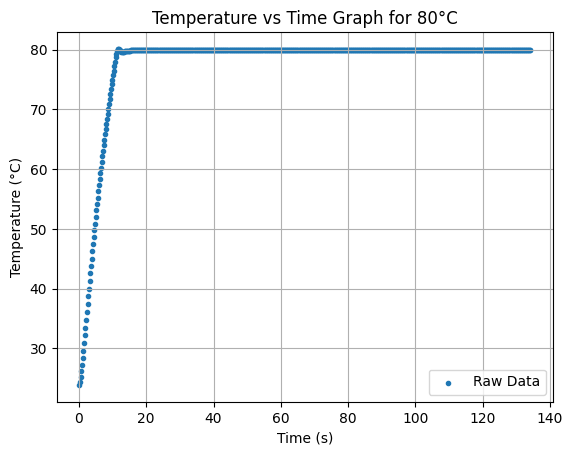

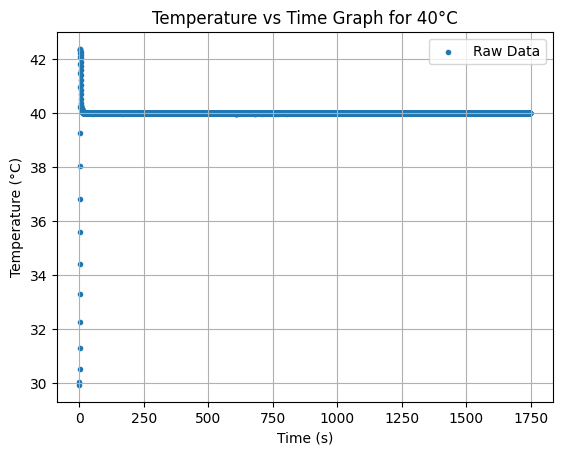

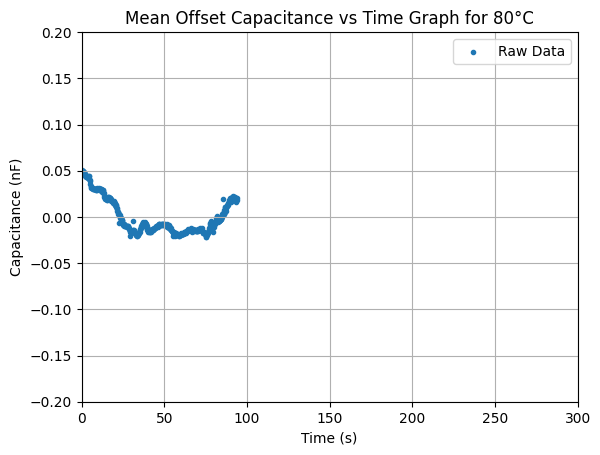

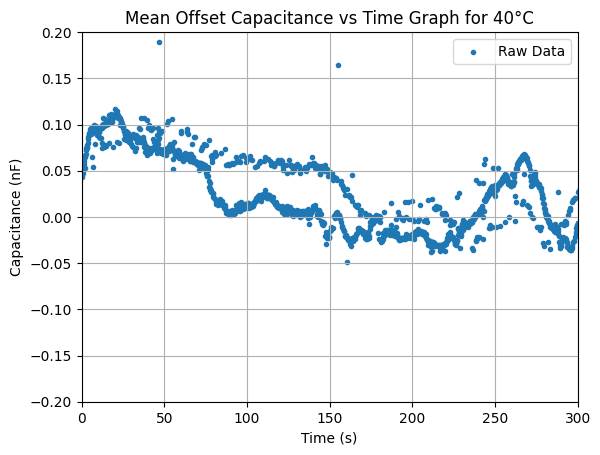

In [118]:
time80, cap80, temp80, power80 = np.genfromtxt("80Short.lvm", delimiter = "\t", skip_header = 1).T
time40, cap40, temp40, power40 = np.genfromtxt("40Long.lvm", delimiter = "\t", skip_header = 1).T


#### Temp vs time


slice80 = 0

slice40 = 0

plt.scatter(time80[slice80:], temp80[slice80:], marker = ".", label = "Raw Data")
# plt.plot(fitTemp, fitCap, color = 'red', label = "Fitted Curve")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Time Graph for 80°C")
plt.grid(True)
plt.legend()
plt.savefig("Graphs/Temp vs Time for 80 Celsius.pdf")
plt.show()



plt.scatter(time40[slice40:], temp40[slice40:], marker = ".", label = "Raw Data")
# plt.plot(fitTemp, fitCap, color = 'red', label = "Fitted Curve")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Time Graph for 40°C")
plt.grid(True)
plt.legend()
plt.savefig("Graphs/Temp vs Time for 40 Celsius.pdf")
plt.show()

#### capacitance vs time (restricted range)

slice80 = 200
slice40 = 80

np.mean(cap80[slice80:])

plt.scatter(time80[slice80:] - time80[slice80:][0], cap80[slice80:] - np.mean(cap80[slice80:]), marker = ".", label = "Raw Data")
# plt.plot(fitTemp, fitCap, color = 'red', label = "Fitted Curve")
plt.xlabel("Time (s)")
plt.ylabel("Capacitance (nF)")
plt.title("Mean Offset Capacitance vs Time Graph for 80°C")
plt.ylim(-0.2, 0.2)
plt.xlim(0, 300)

plt.grid(True)
plt.legend()
plt.savefig("Graphs/Cap vs Time for 80 Celsius.pdf")
plt.show()


plt.scatter(time40[slice40:] - time40[slice40:][0], cap40[slice40:] - np.mean(cap40[slice40:]), marker = ".", label = "Raw Data")
# plt.plot(fitTemp, fitCap, color = 'red', label = "Fitted Curve")
plt.xlabel("Time (s)")
plt.ylabel("Capacitance (nF)")
plt.title("Mean Offset Capacitance vs Time Graph for 40°C")
plt.ylim(-0.2, 0.2)
plt.xlim(0, 300)

plt.grid(True)
plt.legend()
plt.savefig("Graphs/Cap vs Time for 40 Celsius.pdf")
plt.show()



/var/folders/mq/0dfgkp0n0hl1m3490lny0f_m0000gn/T/ipykernel_98583/1925235826.py:5: RuntimeWarning: invalid value encountered in log
  return const * np.log(tempConst / time) + C0


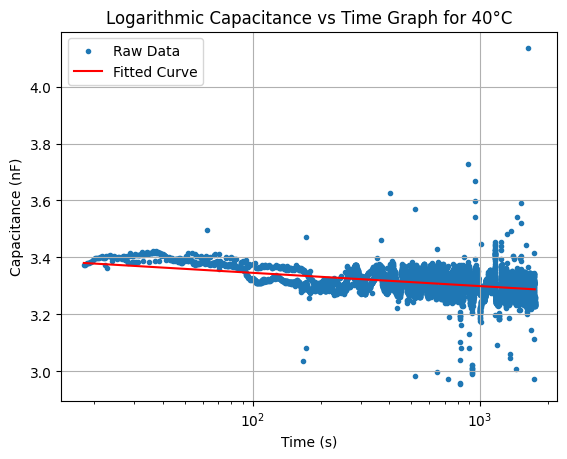

[ 0.02021974 13.29546227  3.38655757]


In [119]:
# log plot and fit


def capModel(time, const, tempConst, C0):
    return const * np.log(tempConst / time) + C0

guesses = [1.5, 40, 3.3]


slice40 = 90

pOpt40, pCov40 = curve_fit(capModel, time40[slice40:], cap40[slice40:], p0 = guesses, maxfev = 100000)

fitTime = np.linspace(time40[slice40:][0], time40[slice40:][-1], 10000)
fitCap = capModel(fitTime, *pOpt40)

plt.scatter(time40[slice40:], cap40[slice40:], marker = ".", label = "Raw Data")
plt.plot(fitTime, fitCap, color = 'red', label = "Fitted Curve")
plt.xlabel("Time (s)")
plt.ylabel("Capacitance (nF)")
plt.xscale("log")
plt.title("Logarithmic Capacitance vs Time Graph for 40°C")
plt.grid(True)
plt.legend()
plt.savefig("Graphs/Logarithmic Cap vs Time for 40 Celsius.pdf")
plt.show()

print(pOpt40)